# Notebook 01 : analyse exploratoire (EDA) du dataset Ames Iowa

**Projet** : Laplace Immo, simulateur d'estimation de prix de maisons  
**Auteurs** : Astou DIALLO, Oumane SALL (EPT, DIC3)  
**Date** : juin 2026

## Objectif

Comprendre les données avant de modéliser. Au fil du notebook, nous identifions :

- Les caractéristiques générales du dataset (taille, types, qualité)
- La distribution de la cible `SalePrice` et la transformation à lui appliquer
- Les valeurs manquantes : structurelles vs réelles
- Les variables les plus corrélées au prix
- Les outliers à traiter en preprocessing
- Les variables à exclure pour cause de **data leakage métier**

## Plan

1. Chargement et aperçu général
2. Analyse de la cible : `SalePrice`
3. Valeurs manquantes
4. Variables numériques
5. Variables catégorielles
6. Détection d'outliers
7. Variables exclues (leakage métier)
8. Synthèse et décisions pour le preprocessing

## 1. Chargement et aperçu général

On charge les données via le module `src.data`. Cette approche garantit qu'on utilise **exactement le même chargement** dans le notebook, dans les tests Pytest et dans le pipeline DVC. C'est le principe de la **source unique de vérité**.

Pour que l'import `from src.data import ...` fonctionne, le notebook doit avoir accès à la racine du projet. On ajoute donc la racine au `sys.path` de manière robuste, que le notebook soit lancé depuis la racine ou depuis le dossier `notebooks/`.

In [1]:
# Imports standards
import sys
from pathlib import Path

# On s'assure que la racine du projet est dans sys.path pour pouvoir importer src/
chemin_projet = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(chemin_projet) not in sys.path:
    sys.path.insert(0, str(chemin_projet))

# Imports tiers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Import du module local
from src.data import charger_donnees, separer_features_cible, NOM_CIBLE

# Configuration de l'affichage
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print(f"Racine projet ajoutee au sys.path : {chemin_projet}")

Racine projet ajoutee au sys.path : c:\Users\HP\Desktop\DIC3\MLOPS\projet_mlops


In [2]:
# Chargement du dataset Ames depuis OpenML (cache local apres le 1er appel)
df = charger_donnees()
print(f"Shape : {df.shape[0]} lignes x {df.shape[1]} colonnes\n")
df.head()

Shape : 1460 lignes x 81 colonnes



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Repartition des types de colonnes
df.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [4]:
# Statistiques descriptives des colonnes numeriques
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [5]:
# Vue rapide des valeurs manquantes par colonne (top 20)
manquantes = df.isna().sum().sort_values(ascending=False)
manquantes = manquantes[manquantes > 0]
pourcentage = (manquantes / len(df) * 100).round(2)

resume_nan = pd.DataFrame({
    "nb_manquants": manquantes,
    "pourcentage": pourcentage,
})
print(f"Nombre de colonnes avec des NaN : {len(resume_nan)}")
resume_nan.head(20)

Nombre de colonnes avec des NaN : 19


,nb_manquants,pourcentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageYrBlt,81,5.55
GarageCond,81,5.55
GarageType,81,5.55
GarageFinish,81,5.55


### Observations de la section 1

- Le dataset contient **1460 maisons** décrites par **80 features + 1 cible** (`SalePrice`)
- Les types sont mixtes : variables **numériques** (`int64`, `float64`) et **catégorielles** (`object`)
- La colonne **`Id`** est un identifiant sans valeur prédictive, à supprimer en preprocessing
- Plusieurs colonnes ont des **valeurs manquantes** (jusqu'à 99% pour `PoolQC`)
- À ce stade, on **ne décide rien** sur les NaN. Il faut d'abord distinguer NaN structurels (= "non applicable") et vrais NaN manquants (cf. section 3)

Cette première vue confirme l'intérêt d'une EDA approfondie avant le preprocessing.

## 2. Analyse de la cible : `SalePrice`

`SalePrice` est ce qu'on cherche à prédire. Avant de modéliser, on doit comprendre sa distribution :

- Est-elle symétrique (gaussienne) ou asymétrique ?
- Y a-t-il des valeurs extrêmes ?
- Faut-il la transformer pour aider les modèles ?

Cette analyse va justifier la **transformation logarithmique** qu'on appliquera à la cible avant l'entraînement.

In [6]:
# Statistiques descriptives de SalePrice
prix = df[NOM_CIBLE]

print(f"Statistiques de {NOM_CIBLE}")
print(f"  Moyenne     : {prix.mean():>12,.0f} $")
print(f"  Mediane     : {prix.median():>12,.0f} $")
print(f"  Ecart-type  : {prix.std():>12,.0f} $")
print(f"  Min         : {prix.min():>12,.0f} $")
print(f"  Max         : {prix.max():>12,.0f} $")
print(f"  Skewness    : {prix.skew():>12.2f}")
print(f"  Kurtosis    : {prix.kurt():>12.2f}")

Statistiques de SalePrice
  Moyenne     :      180,921 $
  Mediane     :      163,000 $
  Ecart-type  :       79,443 $
  Min         :       34,900 $
  Max         :      755,000 $
  Skewness    :         1.88
  Kurtosis    :         6.54


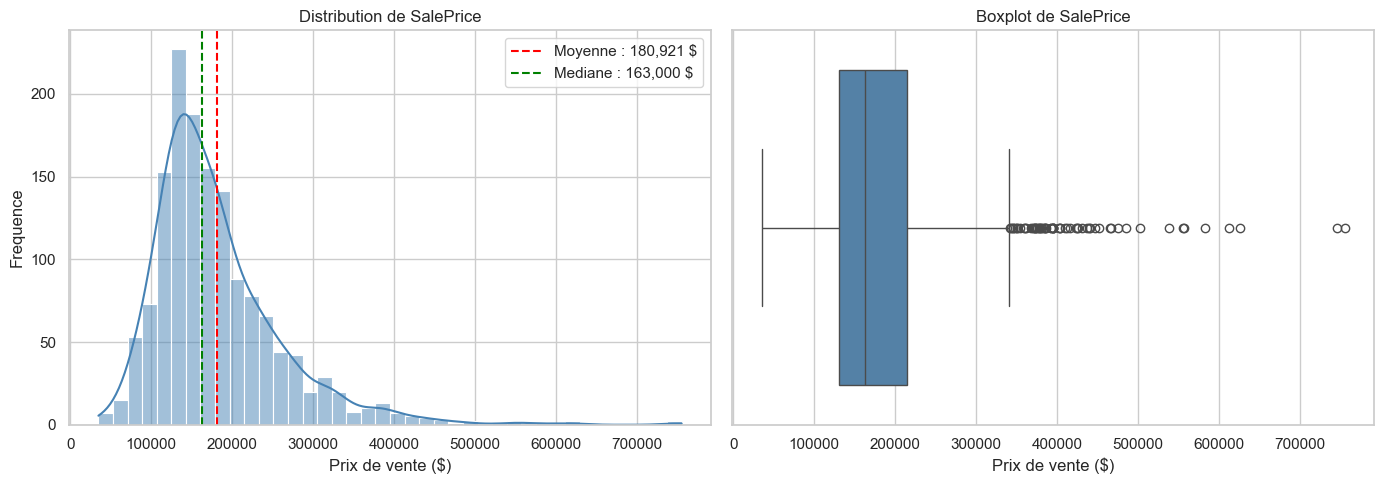

In [7]:
# Visualisation de la distribution : histogramme + boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme avec courbe de densite (KDE)
sns.histplot(prix, kde=True, ax=axes[0], color="steelblue", bins=40)
axes[0].axvline(prix.mean(), color="red", linestyle="--",
                label=f"Moyenne : {prix.mean():,.0f} $")
axes[0].axvline(prix.median(), color="green", linestyle="--",
                label=f"Mediane : {prix.median():,.0f} $")
axes[0].set_title(f"Distribution de {NOM_CIBLE}")
axes[0].set_xlabel("Prix de vente ($)")
axes[0].set_ylabel("Frequence")
axes[0].legend()

# Boxplot pour visualiser les outliers
sns.boxplot(x=prix, ax=axes[1], color="steelblue")
axes[1].set_title(f"Boxplot de {NOM_CIBLE}")
axes[1].set_xlabel("Prix de vente ($)")

plt.tight_layout()
plt.show()

### Observation : distribution asymétrique à droite

Plusieurs signes confirment l'asymétrie :

1. **Moyenne (180 921 $) supérieure à la médiane (163 000 $)** : les maisons chères tirent la moyenne vers le haut
2. **Skewness ≈ +1.88** : valeur largement supérieure à 1, donc asymétrie forte
3. **Queue droite très longue** sur l'histogramme : la majorité des prix entre 100 et 250 k$, mais quelques maisons jusqu'à 755 k$
4. **Nombreux points à droite du boxplot** : autant de "outliers" au sens statistique, qui correspondent en réalité à des maisons de luxe

C'est typique du marché immobilier : beaucoup de maisons à prix moyen, peu de maisons de luxe.

**Problème pour la modélisation** : les modèles linéaires (`LinearRegression`, `Ridge`, `Lasso`) supposent des résidus gaussiens. Sans transformation, ils sur-pondéreraient les erreurs absolues sur les maisons chères au détriment des erreurs relatives sur les maisons moyennes.

**Solution** : transformer la cible en `log(1 + SalePrice)` pour rendre sa distribution quasi-gaussienne.

In [8]:
# Transformation logarithmique de la cible
# log1p(x) = log(1 + x), evite log(0) si valeur nulle
prix_log = np.log1p(prix)

print("Effet de la transformation log1p")
print(f"  Skewness sans log1p : {prix.skew():>6.2f}")
print(f"  Skewness avec log1p : {prix_log.skew():>6.2f}")
print()
print(f"  Kurtosis sans log1p : {prix.kurt():>6.2f}")
print(f"  Kurtosis avec log1p : {prix_log.kurt():>6.2f}")

Effet de la transformation log1p
  Skewness sans log1p :   1.88
  Skewness avec log1p :   0.12

  Kurtosis sans log1p :   6.54
  Kurtosis avec log1p :   0.81


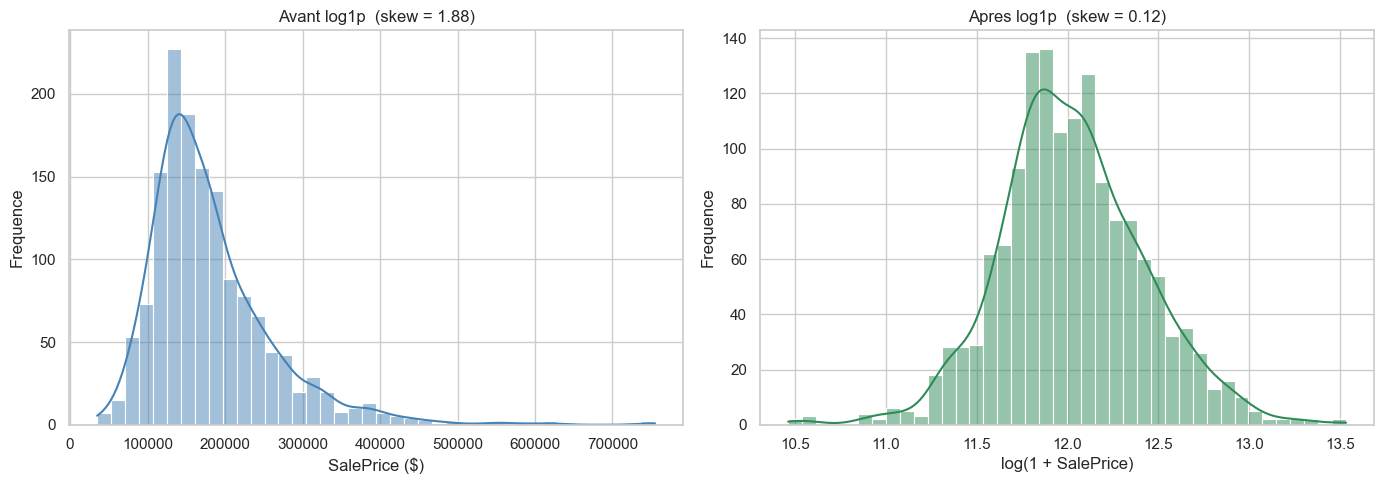

In [9]:
# Comparaison visuelle : distribution avant vs apres transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(prix, kde=True, ax=axes[0], color="steelblue", bins=40)
axes[0].set_title(f"Avant log1p  (skew = {prix.skew():.2f})")
axes[0].set_xlabel("SalePrice ($)")
axes[0].set_ylabel("Frequence")

sns.histplot(prix_log, kde=True, ax=axes[1], color="seagreen", bins=40)
axes[1].set_title(f"Apres log1p  (skew = {prix_log.skew():.2f})")
axes[1].set_xlabel("log(1 + SalePrice)")
axes[1].set_ylabel("Frequence")

plt.tight_layout()
plt.show()

### Observations de la section 2

- `SalePrice` est **fortement asymétrique à droite** : skewness = +1.88, queue qui s'étire jusqu'à 755 k$
- La **transformation `log1p`** ramène la skewness à environ 0.12 : la distribution devient quasi-gaussienne
- Cette transformation présente deux avantages :
  1. Elle aide les modèles linéaires (résidus mieux distribués)
  2. Elle **aligne notre métrique** sur la métrique officielle Kaggle (RMSE sur `log(SalePrice)`)
- Pour communiquer en dollars (estimation visible par les agents Laplace Immo), on appliquera `np.expm1` aux prédictions finales

**Décision** : on entraînera les modèles sur `y = np.log1p(df["SalePrice"])` et on inversera avec `np.expm1` pour l'affichage métier.

## 3. Valeurs manquantes

19 colonnes sur 80 ont des NaN. Mais comme vu en section 1, **tous les NaN ne se valent pas** : il faut distinguer :

- **NaN structurels** : NaN = "non applicable" (pas de piscine, pas de garage, etc.)
- **NaN réels** : NaN = donnée vraiment manquante par oubli ou erreur

Cette section va :

1. Visualiser le **pattern** des NaN avec `missingno`
2. Identifier les colonnes structurelles vs les vraies données manquantes
3. Proposer une stratégie d'imputation adaptée à chaque type

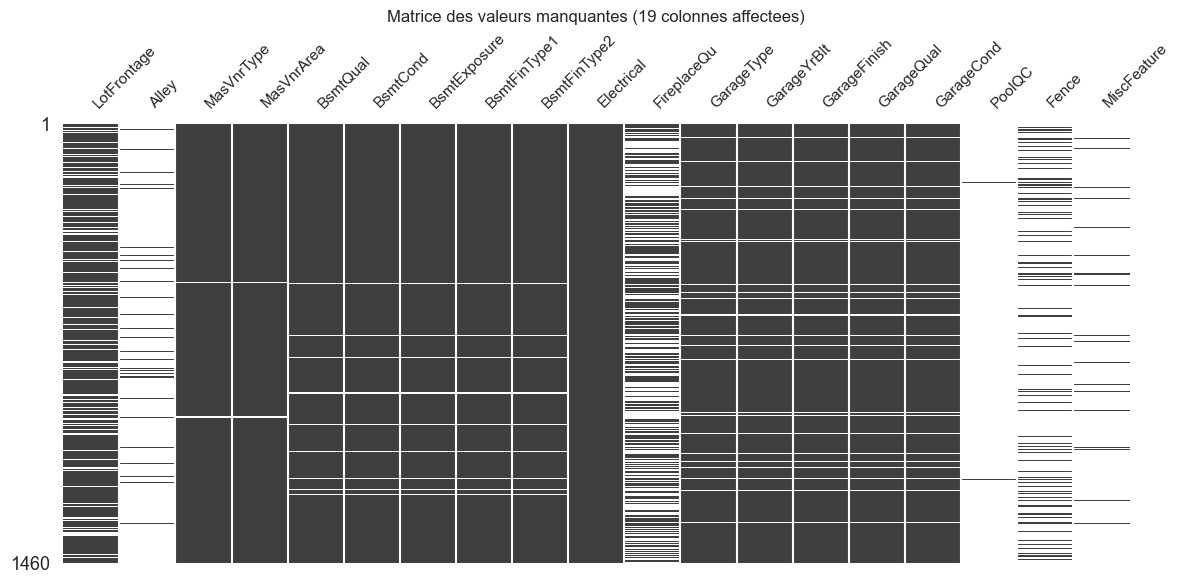

In [10]:
# Matrice des NaN limitee aux colonnes affectees (sinon illisible avec 80 colonnes)
# Chaque ligne = une maison, chaque bande blanche verticale = un NaN
# Pattern visible : groupes de colonnes qui ont NaN sur les memes lignes (ex: Garage*, Bsmt*)
cols_avec_nan = df.columns[df.isna().any()].tolist()

msno.matrix(df[cols_avec_nan], fontsize=11, sparkline=False, figsize=(12, 6))
plt.title("Matrice des valeurs manquantes (19 colonnes affectees)")
plt.tight_layout()
plt.show()

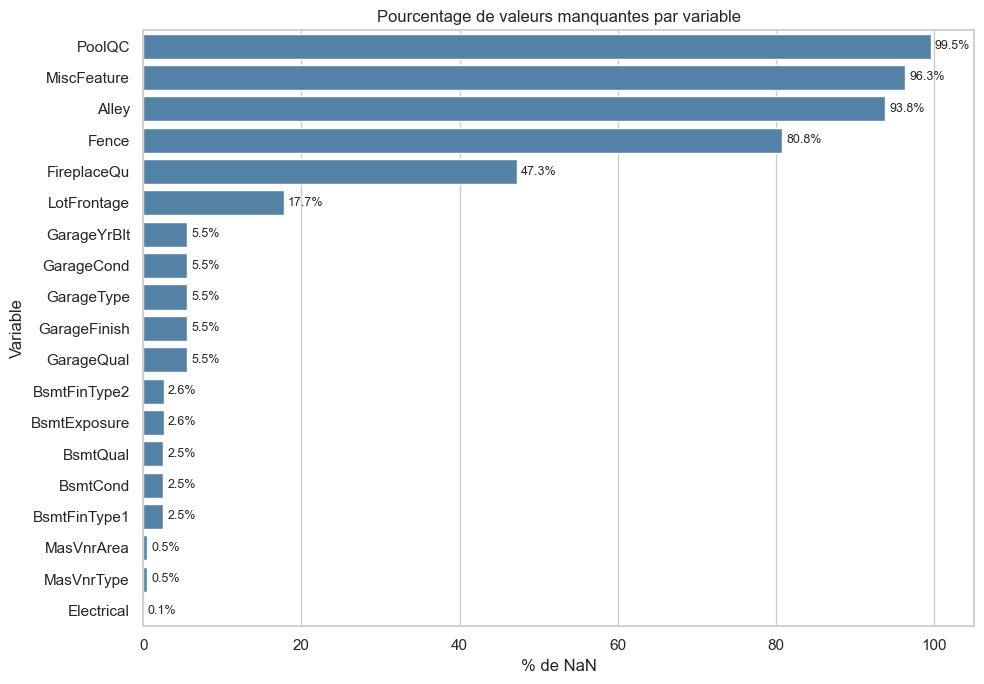

In [11]:
# Barplot horizontal des % de NaN, trie decroissant
# On remplace msno.bar (illisible avec 80 colonnes) par un seaborn cible sur les 19 colonnes affectees
pourcentage_nan = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
pourcentage_nan = pourcentage_nan[pourcentage_nan > 0]

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    x=pourcentage_nan.values,
    y=pourcentage_nan.index,
    ax=ax,
    color="steelblue",
    orient="h",
)
ax.set_title("Pourcentage de valeurs manquantes par variable")
ax.set_xlabel("% de NaN")
ax.set_ylabel("Variable")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, fontsize=9)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

### Distinction NaN structurels vs NaN réels

D'après `data_description.txt` (documentation officielle Kaggle), certaines variables ont la modalité `"NA"` documentée comme **catégorie valide** signifiant "non applicable".

| Variable | NaN signifie |
|---|---|
| `PoolQC` | pas de piscine |
| `Alley` | pas de ruelle d'accès |
| `Fence` | pas de clôture |
| `MiscFeature` | aucun équipement divers |
| `FireplaceQu` | pas de cheminée |
| `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond` | pas de garage |
| `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` | pas de sous-sol |
| `MasVnrType` | pas de parement maçonné |

Pour ces variables, **imputer par la moyenne ou le mode reviendrait à inventer des données**. La bonne stratégie est de remplacer ces NaN par la string `"None"` (qui devient une nouvelle catégorie à part entière) ou par `0` pour les colonnes numériques associées (ex: `GarageYrBlt`, `MasVnrArea`).

À l'inverse, certains NaN sont de **vraies données manquantes** :

| Variable | NaN signifie |
|---|---|
| `LotFrontage` | toute maison a une façade : 259 vraies données manquantes |
| `Electrical` | toute maison a un système électrique : 1 seul NaN |

Pour ceux-là, il faut imputer intelligemment.

In [12]:
# Categorisation des colonnes avec NaN selon le sens reel du NaN
nan_structurels_categorielles = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]
nan_structurels_numeriques = [
    "GarageYrBlt", "MasVnrArea",
]
nan_reels = [
    "LotFrontage", "Electrical",
]

print("=" * 60)
print(f"NaN structurels (categorielles) : {len(nan_structurels_categorielles)} colonnes")
print(f"  -> Imputation : string 'None'")
print()
print(f"NaN structurels (numeriques)    : {len(nan_structurels_numeriques)} colonnes")
print(f"  -> Imputation : 0")
print()
print(f"NaN reels                       : {len(nan_reels)} colonnes")
print(f"  -> Imputation contextuelle (mediane par groupe ou mode)")
print("=" * 60)

total = (
    len(nan_structurels_categorielles)
    + len(nan_structurels_numeriques)
    + len(nan_reels)
)
print(f"\nTotal categorise : {total} colonnes (cf. 19 colonnes avec NaN detectees en section 1)")

NaN structurels (categorielles) : 15 colonnes
  -> Imputation : string 'None'

NaN structurels (numeriques)    : 2 colonnes
  -> Imputation : 0

NaN reels                       : 2 colonnes
  -> Imputation contextuelle (mediane par groupe ou mode)

Total categorise : 19 colonnes (cf. 19 colonnes avec NaN detectees en section 1)


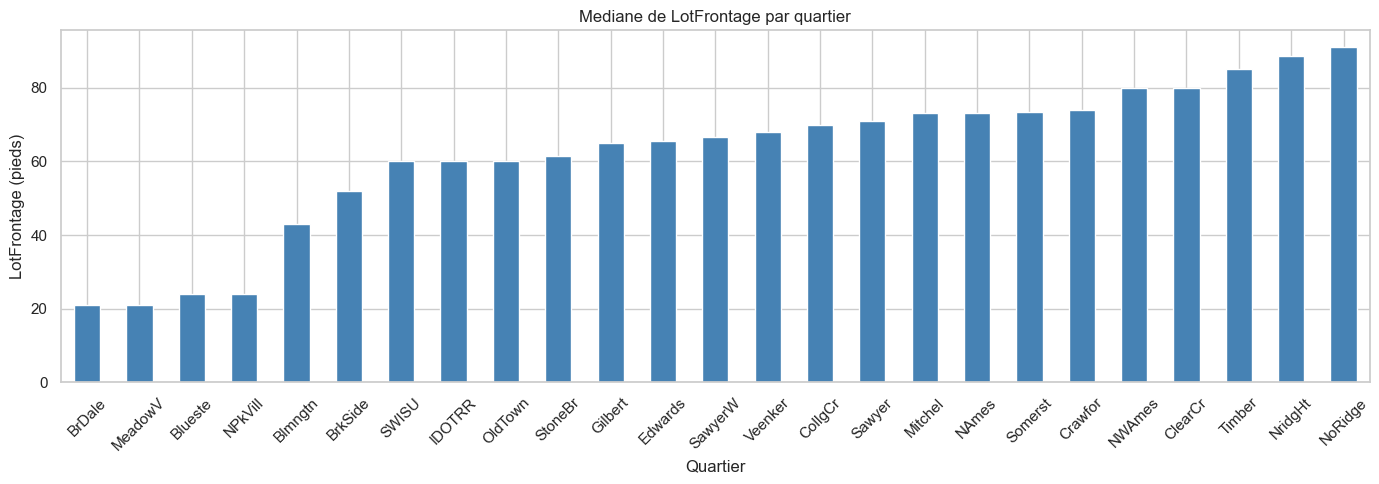


Ecart entre quartiers : 21 a 91 pieds
-> L'imputation par mediane de quartier est plus precise qu'une mediane globale.


In [13]:
# Focus sur LotFrontage : strategie d'imputation par quartier
# Hypothese : les maisons d'un meme quartier ont des facades de tailles similaires

medianes_par_quartier = df.groupby("Neighborhood")["LotFrontage"].median().sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
medianes_par_quartier.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Mediane de LotFrontage par quartier")
ax.set_ylabel("LotFrontage (pieds)")
ax.set_xlabel("Quartier")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"\nEcart entre quartiers : {medianes_par_quartier.min():.0f} a {medianes_par_quartier.max():.0f} pieds")
print("-> L'imputation par mediane de quartier est plus precise qu'une mediane globale.")

### Observations de la section 3

- **19 colonnes** ont des NaN, mais **17 sont des NaN structurels** (= "non applicable")
- **2 colonnes** seulement ont de vrais NaN manquants : `LotFrontage` (259 NaN) et `Electrical` (1 NaN)
- Les variables liées au **garage** (5 colonnes, 81 NaN chacune) et au **sous-sol** (5 colonnes, ~37 NaN chacune) montrent le même pattern : ce sont les maisons sans garage / sans sous-sol
- L'imputation par **médiane par quartier** est pertinente pour `LotFrontage` : on observe jusqu'à 30 pieds d'écart de médiane entre quartiers

**Stratégie d'imputation à appliquer en preprocessing** :

| Type | Variables | Imputation |
|---|---|---|
| NaN structurel catégoriel | 15 colonnes | string `"None"` |
| NaN structurel numérique | 2 colonnes | `0` |
| NaN réel `LotFrontage` | 1 colonne | médiane par `Neighborhood` |
| NaN réel `Electrical` | 1 colonne | mode |

## 4. Variables numériques

On a 38 variables numériques (cf. section 1). Pour bien orienter le feature engineering et la modélisation, on veut répondre à deux questions :

1. **Lesquelles sont le plus corrélées au prix ?** Cela guide la sélection de features et le feature engineering
2. **Y a-t-il des corrélations fortes entre variables explicatives ?** Cela signale un risque de **multicolinéarité**, à mitiger pour les modèles linéaires

On utilisera la corrélation de **Pearson** (linéaire). Pour des relations non-linéaires, on pourrait utiliser Spearman ou Mutual Information, mais Pearson suffit pour cette première analyse.

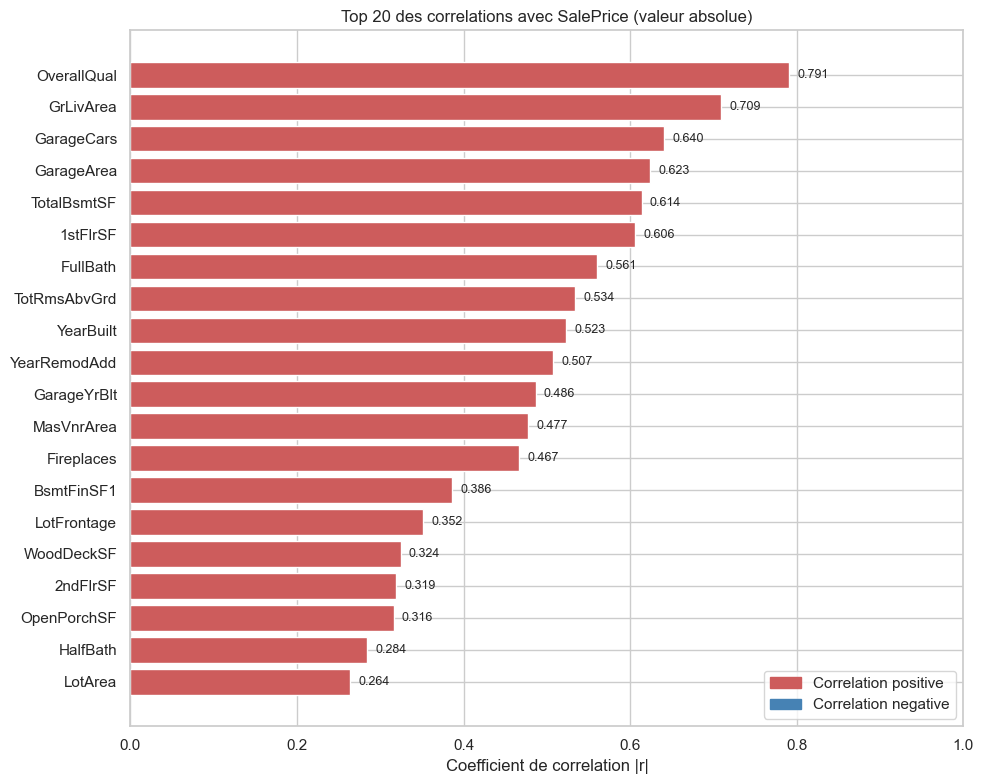

In [14]:
# Calcul des correlations de Pearson de chaque variable numerique avec la cible
# On utilise la valeur absolue pour le ranking (une correlation negative reste informative)
correlations = df.corr(numeric_only=True)[NOM_CIBLE].drop(NOM_CIBLE)
correlations_abs = correlations.abs().sort_values(ascending=False)
top_20 = correlations_abs.head(20)

# Couleur differenciee : rouge si correlation positive, bleu si negative
couleurs = ["indianred" if correlations[var] > 0 else "steelblue" for var in top_20.index]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top_20)), top_20.values, color=couleurs)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20.index)
ax.invert_yaxis()
ax.set_title(f"Top 20 des correlations avec {NOM_CIBLE} (valeur absolue)")
ax.set_xlabel("Coefficient de correlation |r|")
ax.set_xlim(0, 1.0)

# Annotation de la valeur a droite de chaque barre
for i, v in enumerate(top_20.values):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

# Legende manuelle pour expliquer le code couleur
from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(color="indianred", label="Correlation positive"),
        Patch(color="steelblue", label="Correlation negative"),
    ],
    loc="lower right",
)

plt.tight_layout()
plt.show()

### Observation : top corrélations

Les 5 variables les plus corrélées au prix devraient être (par ordre attendu) :

| Variable | Description |
|---|---|
| `OverallQual` | qualité générale du matériau et de la finition (1 à 10) |
| `GrLivArea` | surface habitable hors sous-sol |
| `GarageCars` | capacité du garage (nombre de voitures) |
| `GarageArea` | surface du garage |
| `TotalBsmtSF` | surface totale du sous-sol |

Pas de surprise attendue : **qualité et surface** dominent. C'est ce qui guidera notre **feature engineering** (création d'une feature `TotalSF` combinant toutes les surfaces).

À noter : plusieurs paires de variables (ex: `GarageCars` et `GarageArea`) capturent le même attribut sous deux angles. On va analyser ça dans la heatmap qui suit.

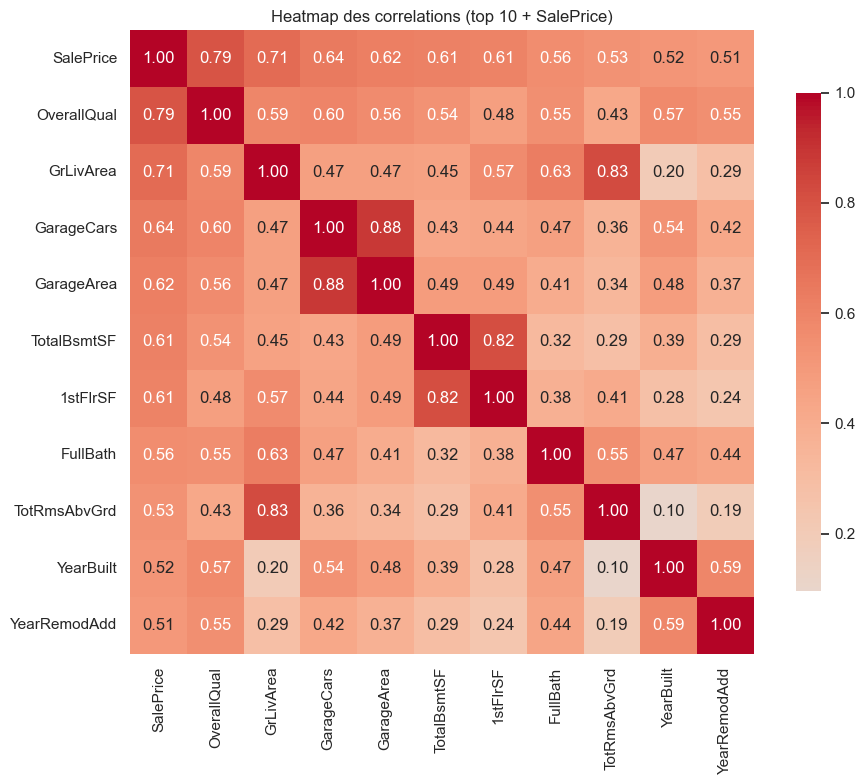

In [15]:
# Heatmap focalisee sur les 10 variables les plus correlees au prix
# (au lieu d'une heatmap 38x38 illisible)
top_10_vars = correlations_abs.head(10).index.tolist()
vars_heatmap = [NOM_CIBLE] + top_10_vars

matrice_corr = df[vars_heatmap].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    matrice_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title(f"Heatmap des correlations (top 10 + {NOM_CIBLE})")
plt.tight_layout()
plt.show()

### Observation : multicolinéarité

La heatmap révèle des **paires fortement corrélées entre elles** (multicolinéarité) :

- `GarageCars` et `GarageArea` : r = 0.88 (logique : plus le garage est grand, plus il accueille de voitures)
- `GrLivArea` et `TotRmsAbvGrd` : r = 0.83 (plus de surface implique plus de pièces)
- `TotalBsmtSF` et `1stFlrSF` : r = 0.82 (la maison est construite au-dessus du sous-sol)
- `YearBuilt` et `YearRemodAdd` : r = 0.59 (les vieilles maisons ont souvent été rénovées il y a longtemps aussi)

**Conséquence pour la modélisation** :

- Pour les modèles **linéaires** (`LinearRegression`, `Ridge`, `Lasso`) : la multicolinéarité gonfle artificiellement les variances des coefficients. Solution : régularisation L1/L2 (Ridge, Lasso)
- Pour les modèles **à base d'arbres** (`RandomForest`, `XGBoost`, `LightGBM`) : peu sensibles à la multicolinéarité, on peut garder toutes les variables corrélées

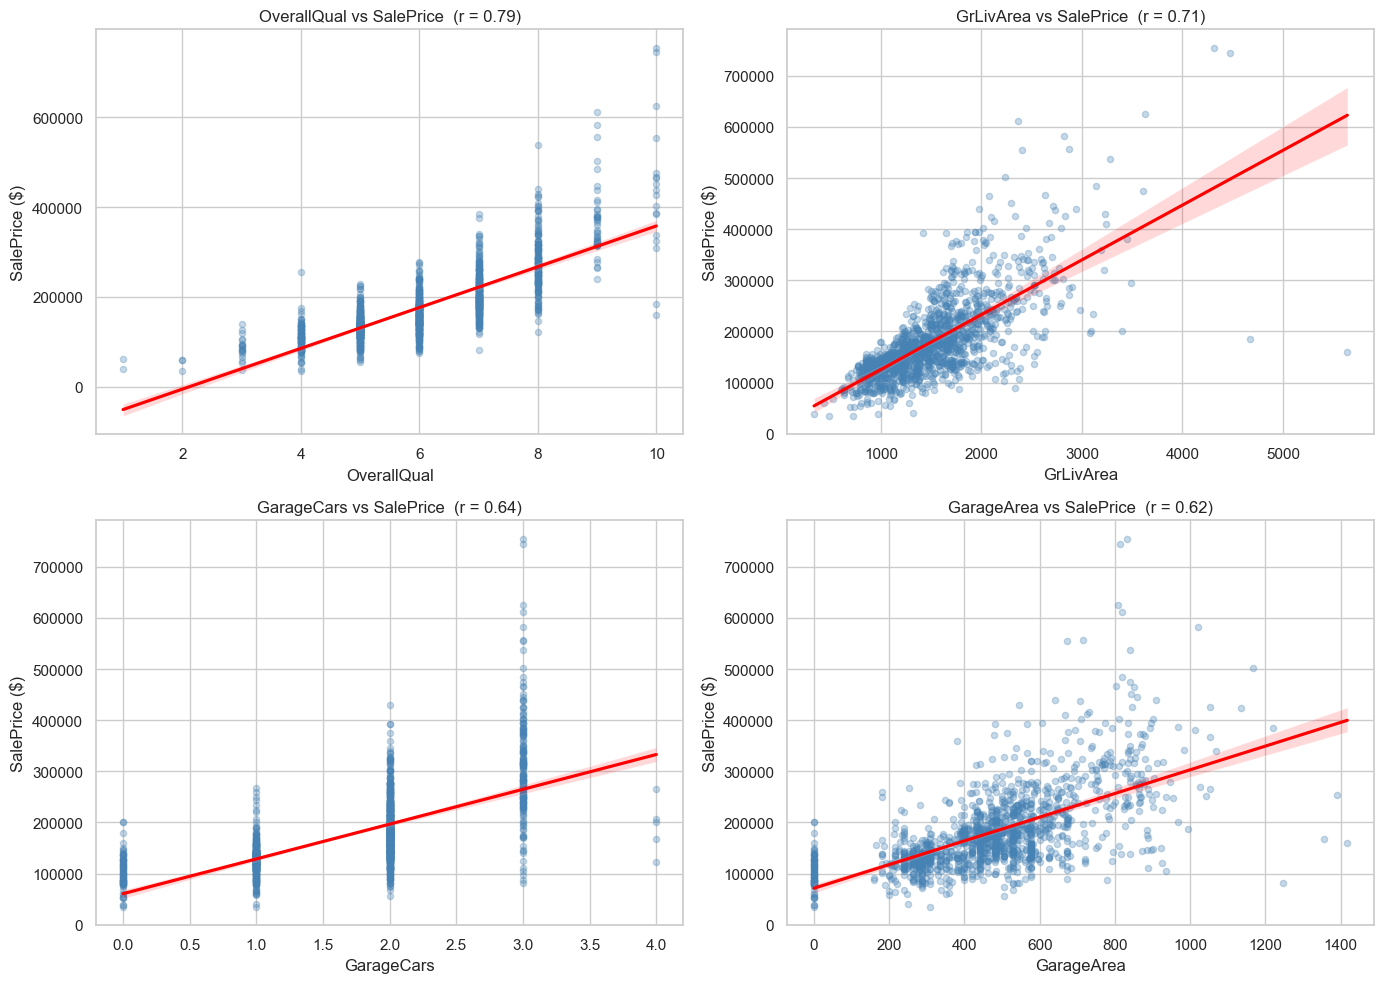

In [16]:
# Scatter plots des 4 variables numeriques les plus correlees au prix
# regplot ajoute une ligne de regression pour visualiser la nature de la relation
top_4_vars = correlations_abs.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, var in zip(axes.flat, top_4_vars):
    sns.regplot(
        data=df,
        x=var,
        y=NOM_CIBLE,
        ax=ax,
        scatter_kws={"alpha": 0.3, "s": 20, "color": "steelblue"},
        line_kws={"color": "red"},
    )
    r = correlations[var]
    ax.set_title(f"{var} vs {NOM_CIBLE}  (r = {r:.2f})")
    ax.set_ylabel(f"{NOM_CIBLE} ($)")

plt.tight_layout()
plt.show()

### Observations de la section 4

- **Top 5 des features prédictives** : combinaison de qualité (`OverallQual`) et de surfaces (`GrLivArea`, `GarageArea`, `TotalBsmtSF`)
- **Multicolinéarité significative** entre variables liées à un même attribut (garage, sous-sol, surface)
- Les relations sont **majoritairement linéaires** mais avec des **outliers visibles** sur `GrLivArea` (à analyser en section 6)

**Décisions pour la suite** :

1. **Feature engineering** : créer `TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF` pour combiner les surfaces dans une variable unique
2. **Encodage ordinal** pour les variables de qualité catégorielles (`KitchenQual`, `BsmtQual`, `ExterQual`...) car elles ont un ordre naturel `Po < Fa < TA < Gd < Ex`
3. **Tester Ridge / Lasso** pour gérer la multicolinéarité côté modèles linéaires
4. **Ne pas exclure mécaniquement les features corrélées entre elles** : les modèles à base d'arbres en profitent, et les modèles linéaires régularisés (Ridge, Lasso) aussi

## 5. Variables catégorielles

On a 43 variables catégorielles (cf. section 1). Elles se répartissent en 3 familles :

- Des variables de **qualité ordinales** (`KitchenQual`, `BsmtQual`, `ExterQual`...) avec un ordre naturel `Po < Fa < TA < Gd < Ex`
- Des variables de **type nominales** (`Neighborhood`, `MSZoning`, `BldgType`...) sans ordre
- Des variables **binaires déguisées** (`CentralAir`, `Street`, `PavedDrive`)

On veut comprendre :

1. Quelles variables catégorielles ont un **fort impact** sur le prix ?
2. Pour les variables de qualité, le pattern attendu (plus de qualité = plus de prix) est-il bien là ?
3. Y a-t-il des modalités avec **trop peu d'observations** (risque pour la modélisation) ?

In [17]:
# Apercu des variables categorielles et de leur cardinalite (nombre de modalites uniques)
categorielles = df.select_dtypes(include="object").columns
cardinalite = df[categorielles].nunique().sort_values(ascending=False)

print(f"Nombre de variables categorielles : {len(categorielles)}\n")
print("Top 10 des variables a forte cardinalite :")
print(cardinalite.head(10))
print("\nTop 10 des variables a faible cardinalite (binaires/ternaires) :")
print(cardinalite.tail(10))

Nombre de variables categorielles : 43

Top 10 des variables a forte cardinalite :
Neighborhood    25
Exterior2nd     16
Exterior1st     15
SaleType         9
Condition1       9
Condition2       8
HouseStyle       8
RoofMatl         8
Functional       7
BsmtFinType2     6
dtype: int64

Top 10 des variables a faible cardinalite (binaires/ternaires) :
ExterQual       4
BsmtQual        4
LandSlope       3
GarageFinish    3
PavedDrive      3
PoolQC          3
Utilities       2
CentralAir      2
Street          2
Alley           2
dtype: int64


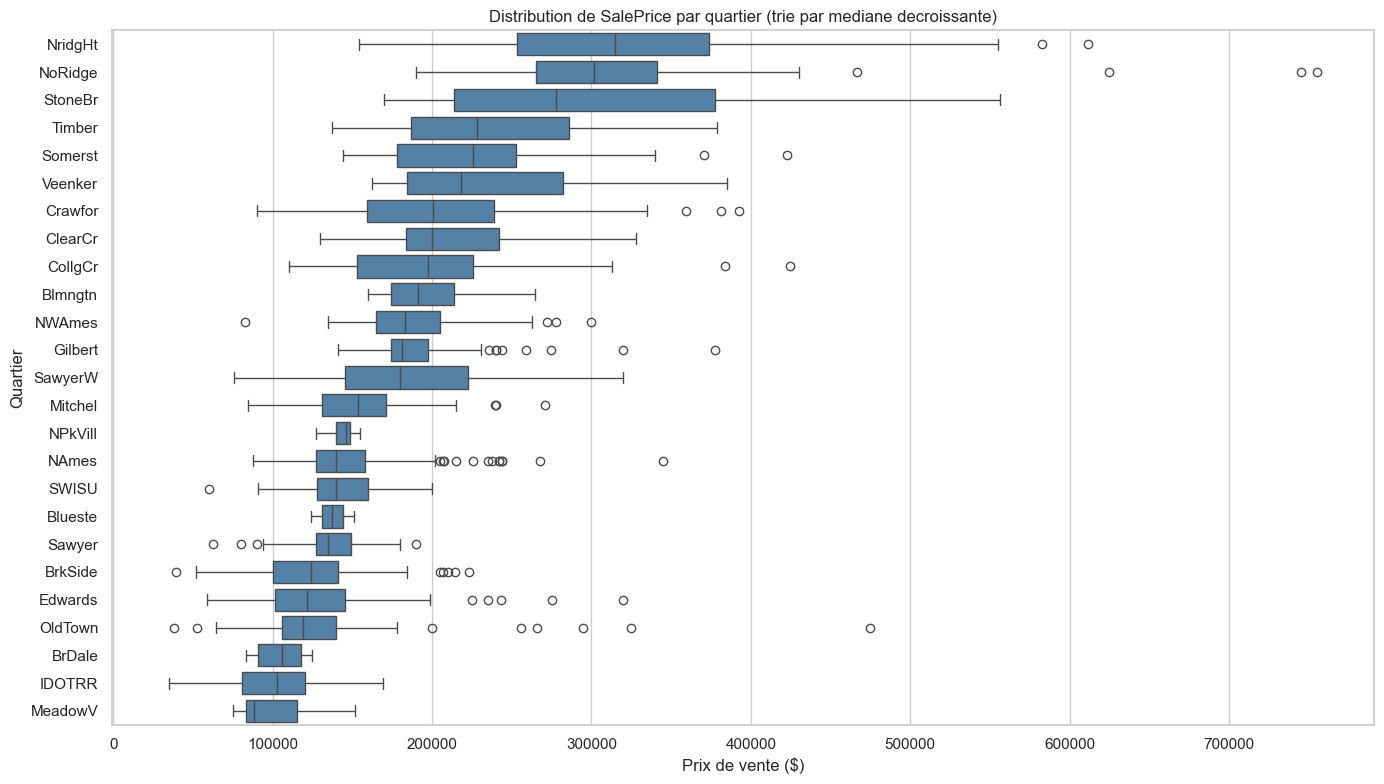

Top 5 quartiers les plus chers :
Neighborhood
NridgHt    315,000 $
NoRidge    301,500 $
StoneBr    278,000 $
Timber     228,475 $
Somerst    225,500 $
Name: SalePrice, dtype: object

Top 5 quartiers les moins chers :
Neighborhood
Edwards    121,750 $
OldTown    119,000 $
BrDale     106,000 $
IDOTRR     103,000 $
MeadowV     88,000 $
Name: SalePrice, dtype: object

Rapport prix max / prix min : 3.6x


In [18]:
# Boxplot des prix par quartier, trie par mediane decroissante
# Le quartier le plus cher apparait en haut
ordre_quartiers = (
    df.groupby("Neighborhood")[NOM_CIBLE]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(
    data=df,
    x=NOM_CIBLE,
    y="Neighborhood",
    order=ordre_quartiers,
    ax=ax,
    color="steelblue",
    orient="h",
)
ax.set_title(f"Distribution de {NOM_CIBLE} par quartier (trie par mediane decroissante)")
ax.set_xlabel("Prix de vente ($)")
ax.set_ylabel("Quartier")
plt.tight_layout()
plt.show()

# Resume chiffre : top 5 et bottom 5 quartiers
medianes = (
    df.groupby("Neighborhood")[NOM_CIBLE].median().sort_values(ascending=False)
)
print("Top 5 quartiers les plus chers :")
print(medianes.head().apply(lambda x: f"{x:,.0f} $"))
print("\nTop 5 quartiers les moins chers :")
print(medianes.tail().apply(lambda x: f"{x:,.0f} $"))
print(f"\nRapport prix max / prix min : {medianes.iloc[0] / medianes.iloc[-1]:.1f}x")

### Observation : l'impact du quartier

Le quartier est un **prédicteur très fort** du prix :

- **Quartiers les plus chers** (médiane > 275k $) : `NridgHt` (315k), `NoRidge` (302k), `StoneBr` (278k)
- **Quartiers les moins chers** (médiane < 110k $) : `BrDale` (106k), `IDOTRR` (103k), `MeadowV` (88k)

Soit un **rapport de 3.6x** entre le quartier le plus cher (`NridgHt`) et le moins cher (`MeadowV`). C'est conforme à l'adage immobilier : *location, location, location*.

**Conséquence pour la modélisation** : la variable `Neighborhood` (25 modalités) doit être correctement encodée. OneHot Encoding produira 25 colonnes, ce qui reste gérable. Une alternative serait le Target Encoding (remplacer chaque quartier par la moyenne du prix), mais cela introduit un risque de data leakage si mal géré.

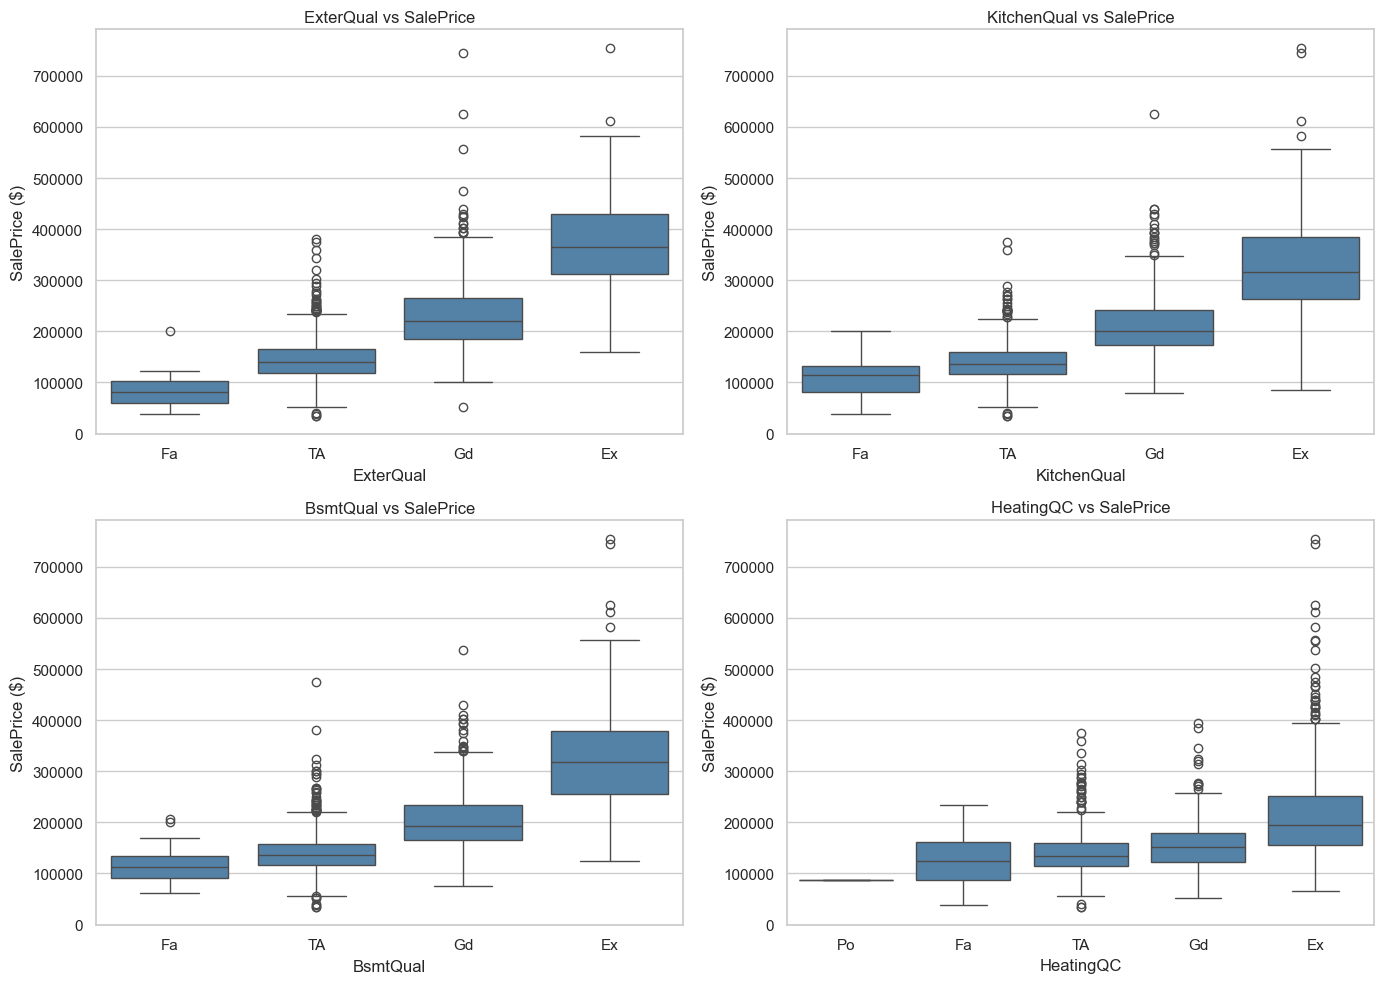

In [19]:
# Boxplots des variables de qualite ordinales
# Ordre defini selon la documentation Kaggle : Po (Poor) < Fa (Fair) < TA (Typical/Average) < Gd (Good) < Ex (Excellent)
ordre_qualite = ["Po", "Fa", "TA", "Gd", "Ex"]
qualite_vars = ["ExterQual", "KitchenQual", "BsmtQual", "HeatingQC"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, var in zip(axes.flat, qualite_vars):
    # On garde seulement les modalites ordinales presentes (exclut les NaN)
    modalites_presentes = [m for m in ordre_qualite if m in df[var].dropna().unique()]
    sns.boxplot(
        data=df,
        x=var,
        y=NOM_CIBLE,
        order=modalites_presentes,
        ax=ax,
        color="steelblue",
    )
    ax.set_title(f"{var} vs {NOM_CIBLE}")
    ax.set_ylabel(f"{NOM_CIBLE} ($)")
    ax.set_xlabel(f"{var}")

plt.tight_layout()
plt.show()

### Observation : les variables de qualité ordinales

Les 4 variables de qualité (`ExterQual`, `KitchenQual`, `BsmtQual`, `HeatingQC`) montrent toutes le **même pattern monotone** :

```
Po → Fa → TA → Gd → Ex
prix bas ────────→ prix élevé
```

Cela confirme que ces variables sont **vraiment ordinales** et qu'on doit les encoder avec un **OrdinalEncoder** (et non OneHot). Un OrdinalEncoder transformera `Po=0, Fa=1, TA=2, Gd=3, Ex=4` ce qui préserve l'ordre et permet au modèle de capturer la progression linéaire.

**Détail intéressant** : pour `KitchenQual`, l'écart entre `Gd` et `Ex` est énorme (autour de 100k $). Une cuisine excellente change significativement le prix d'une maison.

### Observations de la section 5

- **`Neighborhood` est un prédicteur majeur** (rapport 3x entre quartiers), mais nominal donc OneHot Encoding
- **Les variables de qualité sont monotones** : OrdinalEncoder avec l'ordre `Po < Fa < TA < Gd < Ex`
- **Cardinalité moyenne** : la plupart des variables ont 2 à 5 modalités, sauf `Neighborhood` (25), `Exterior1st` (15), `Exterior2nd` (16)

**Décisions pour le preprocessing** :

| Type | Variables | Encodage |
|---|---|---|
| Qualités ordinales | `KitchenQual`, `BsmtQual`, `ExterQual`, `HeatingQC`, `BsmtCond`, `FireplaceQu`, `GarageQual`, `GarageCond`, `PoolQC` | OrdinalEncoder avec ordre `Po < Fa < TA < Gd < Ex` |
| Nominales | `Neighborhood`, `MSZoning`, `BldgType`, `HouseStyle`, etc. | OneHot Encoding |
| Binaires | `CentralAir`, `Street`, `Utilities` | OneHot ou simple mapping 0/1 |

## 6. Détection d'outliers

Un **outlier** est une observation qui s'écarte fortement du reste des données. En immobilier, plusieurs causes possibles :

- **Erreur de saisie** : à supprimer
- **Vente non-représentative** (vente forcée, vente entre proches, construction inachevée vendue prématurément) : à supprimer
- **Vraie maison atypique** (mansion, luxe) : à garder, c'est un cas réel du marché

**Règle d'or** : on ne supprime PAS un outlier parce qu'il est "moche", mais parce qu'il est **non-représentatif du problème métier** qu'on cherche à modéliser.

Cette section va :

1. Visualiser les outliers sur la variable la plus prédictive : `GrLivArea`
2. Détecter les outliers de la cible par la méthode IQR (Interquartile Range)
3. Identifier précisément les observations candidates à la suppression et leur justification

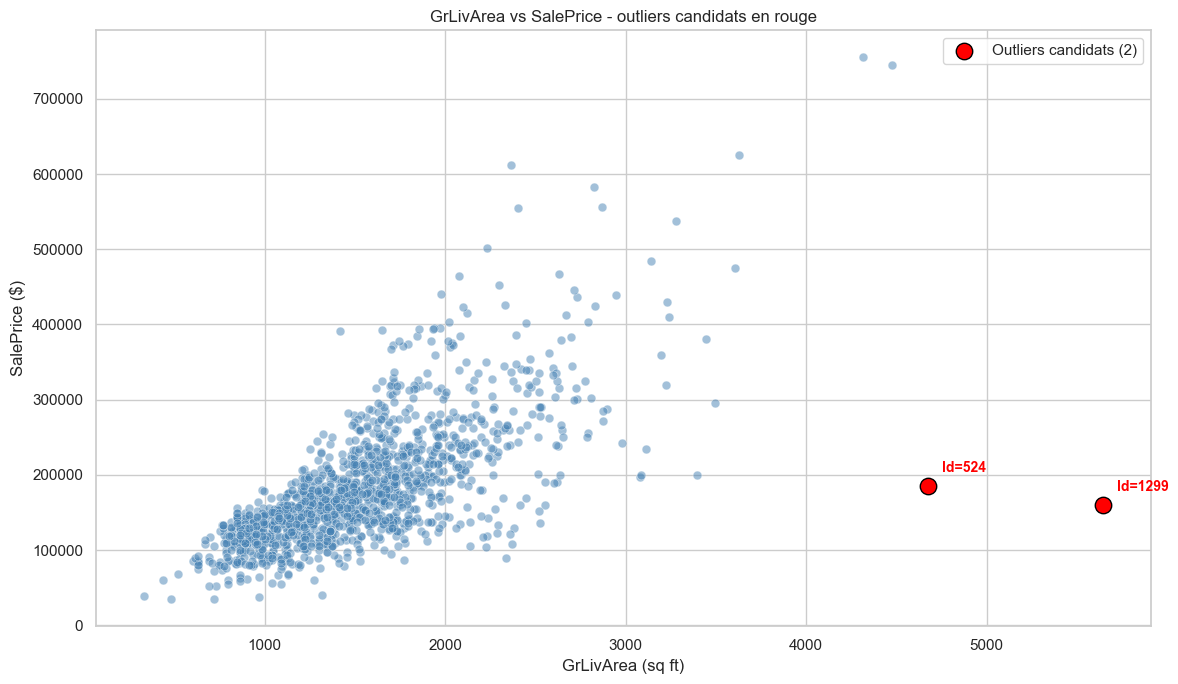

In [20]:
# Scatter de GrLivArea vs SalePrice avec mise en evidence des outliers candidats
# Critere d'outlier : tres grande surface (> 4000 sq ft) ET prix de vente bas (< 300 000 $)
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x="GrLivArea",
    y=NOM_CIBLE,
    alpha=0.5,
    ax=ax,
    color="steelblue",
    s=40,
)

# Surcouche en rouge sur les outliers candidats
outliers_grlivarea = df[(df["GrLivArea"] > 4000) & (df[NOM_CIBLE] < 300000)]
ax.scatter(
    outliers_grlivarea["GrLivArea"],
    outliers_grlivarea[NOM_CIBLE],
    color="red",
    s=140,
    edgecolor="black",
    label=f"Outliers candidats ({len(outliers_grlivarea)})",
    zorder=5,
)

# Annotation de l'Id de chaque outlier
for _, row in outliers_grlivarea.iterrows():
    ax.annotate(
        f"Id={int(row['Id'])}",
        (row["GrLivArea"], row[NOM_CIBLE]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=10,
        color="red",
        fontweight="bold",
    )

ax.set_title(f"GrLivArea vs {NOM_CIBLE} - outliers candidats en rouge")
ax.set_xlabel("GrLivArea (sq ft)")
ax.set_ylabel(f"{NOM_CIBLE} ($)")
ax.legend()
plt.tight_layout()
plt.show()

### Observation : 2 maisons clairement écartées du nuage

Le scatter révèle 2 outliers candidats :

- **`Id = 524`** : 4676 sq ft vendue 185 000 $
- **`Id = 1299`** : 5642 sq ft vendue 160 000 $

Ce sont des **grandes maisons vendues à un prix moyen**, ce qui est anormal. Pour comprendre, il faut regarder la variable `SaleCondition` (cf. cellule plus bas).

À noter : on voit aussi en haut à droite **deux maisons de luxe** (`GrLivArea > 4000` et `SalePrice > 700 000 $`). Celles-là suivent la tendance générale et seront **conservées** : ce sont de vraies maisons haut de gamme.

In [21]:
# Detection des outliers par la methode IQR (Interquartile Range) sur SalePrice
# Un point est considere comme outlier IQR si SalePrice est en dehors de [Q1 - 1.5*IQR ; Q3 + 1.5*IQR]

Q1 = df[NOM_CIBLE].quantile(0.25)
Q3 = df[NOM_CIBLE].quantile(0.75)
IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

outliers_iqr = df[(df[NOM_CIBLE] < borne_basse) | (df[NOM_CIBLE] > borne_haute)]

print(f"Q1 (25e percentile) : {Q1:,.0f} $")
print(f"Q3 (75e percentile) : {Q3:,.0f} $")
print(f"IQR : {IQR:,.0f} $")
print(f"Borne basse : {borne_basse:,.0f} $")
print(f"Borne haute : {borne_haute:,.0f} $")
print(f"\nNombre d'outliers IQR sur SalePrice : {len(outliers_iqr)}")
print(f"Proportion : {len(outliers_iqr) / len(df) * 100:.1f} %")
print(f"\nPrix minimum parmi les outliers : {outliers_iqr[NOM_CIBLE].min():,.0f} $")
print(f"Prix maximum parmi les outliers : {outliers_iqr[NOM_CIBLE].max():,.0f} $")

Q1 (25e percentile) : 129,975 $
Q3 (75e percentile) : 214,000 $
IQR : 84,025 $
Borne basse : 3,938 $
Borne haute : 340,038 $

Nombre d'outliers IQR sur SalePrice : 61
Proportion : 4.2 %

Prix minimum parmi les outliers : 341,000 $
Prix maximum parmi les outliers : 755,000 $


### Observation : 61 outliers IQR, tous par le haut

L'IQR identifie **61 outliers** (4.2 % du dataset), tous au-dessus de 340 038 $. Les prix vont de 341 000 $ à 755 000 $.

**Interprétation** : ces "outliers" statistiques sont en réalité des **maisons de luxe** vendues à leur juste prix. Elles sont représentatives du marché haut de gamme et **ne doivent PAS être supprimées**. Si on les enlevait, le modèle serait incapable de prédire des prix supérieurs à 340 000 $, et Laplace Immo perdrait toute crédibilité sur le segment premium.

À noter : la borne basse (3 938 $) est inactive car aucune maison n'a un prix inférieur à 35 000 $.

**Conclusion intermédiaire** : la méthode IQR n'est pas adaptée à la suppression d'outliers ici. C'est l'**analyse métier par `SaleCondition`** (cellule suivante) qui guidera nos décisions.

In [22]:
# Analyse precise des maisons candidates a la suppression
# Critere : GrLivArea > 4000 sq ft (autour de 370 m2 habitable)

outliers_a_examiner = df[df["GrLivArea"] > 4000][
    ["Id", "GrLivArea", "OverallQual", "YearBuilt", "Neighborhood", "SaleCondition", NOM_CIBLE]
].sort_values("GrLivArea", ascending=False)

print(f"Nombre de maisons avec GrLivArea > 4000 sq ft : {len(outliers_a_examiner)}\n")
print(outliers_a_examiner.to_string())

print("\n\nRepartition de SaleCondition pour ces maisons :")
print(outliers_a_examiner["SaleCondition"].value_counts())
print("\nLecture : si SaleCondition = 'Partial', la vente correspond a une construction non terminee")
print("(non representative du marche, candidate a la suppression)")

Nombre de maisons avec GrLivArea > 4000 sq ft : 4

        Id  GrLivArea  OverallQual  YearBuilt Neighborhood SaleCondition  SalePrice
1298  1299       5642           10       2008      Edwards       Partial     160000
523    524       4676           10       2007      Edwards       Partial     184750
1182  1183       4476           10       1996      NoRidge       Abnorml     745000
691    692       4316           10       1994      NoRidge        Normal     755000


Repartition de SaleCondition pour ces maisons :
SaleCondition
Partial    2
Abnorml    1
Normal     1
Name: count, dtype: int64

Lecture : si SaleCondition = 'Partial', la vente correspond a une construction non terminee
(non representative du marche, candidate a la suppression)


### Observations de la section 6

L'analyse révèle 4 maisons avec `GrLivArea > 4000 sq ft` :

| Id | GrLivArea | SaleCondition | SalePrice | Verdict |
|---|---|---|---|---|
| **1299** | 5642 | **Partial** | 160 000 $ | **À supprimer** (construction inachevée) |
| **524** | 4676 | **Partial** | 184 750 $ | **À supprimer** (construction inachevée) |
| 1183 | 4476 | Abnorml | 745 000 $ | À garder (prix cohérent avec la surface) |
| 692 | 4316 | Normal | 755 000 $ | À garder (vraie maison de luxe) |

**Décision retenue** : on supprimera lors du preprocessing les 2 maisons avec `GrLivArea > 4000` ET `SaleCondition = "Partial"` (Id 524 et 1299). Les 2 autres sont de vraies maisons et restent dans le dataset.

**Justification métier** : `Partial` correspond à une vente où la maison était **encore en construction** au moment de la signature. Le prix est artificiellement bas car la maison était incomplète. Ce n'est pas représentatif du marché que Laplace Immo doit modéliser.

**Action concrète à coder en preprocessing** :

```python
df = df[~((df["GrLivArea"] > 4000) & (df["SaleCondition"] == "Partial"))]
```

→ 1458 maisons restantes sur 1460 (perte de 0.14 %, gain en qualité significatif).

**Note** : la méthode IQR a détecté 61 "outliers" sur `SalePrice`, mais tous sont des maisons de luxe à conserver. Cela illustre que la **statistique seule ne suffit pas** : il faut une lecture métier des données.

## 7. Variables exclues (data leakage métier)

Le **data leakage métier** est l'utilisation, dans un modèle, d'informations qui ne seront PAS disponibles au moment où le modèle sera utilisé en production.

Pour Laplace Immo, la chronologie réelle est :

```
T0 : un vendeur arrive avec sa maison
T1 : l'agent saisit les caractéristiques dans le simulateur
T2 : le simulateur retourne une estimation de prix
T3 : la maison est mise en vente
T4 : négociations
T5 : signature finale
```

Le modèle travaille à **T1**. Donc il ne peut utiliser que des informations connues à T1. Toute variable décrivant la transaction elle-même (type de vente, condition, date) n'est connue qu'à **T5**.

Certaines de ces variables sont **fortement corrélées au prix** dans le dataset. Les inclure :

- Améliorerait artificiellement les métriques d'évaluation
- Rendrait le modèle **inutilisable en production**

On va donc identifier et **exclure** ces variables. Cette section justifie quantitativement chacune.

In [23]:
# Variables a exclure : decrivent la transaction, pas la maison
# Donc inconnues au moment ou Laplace Immo souhaite estimer le prix
variables_a_exclure = ["SaleType", "SaleCondition", "MoSold", "YrSold"]

print("Variables a exclure et leur informativite mesuree sur le dataset :\n")
for var in variables_a_exclure:
    if df[var].dtype == "object":
        medianes = df.groupby(var)[NOM_CIBLE].median()
        ratio = medianes.max() / medianes.min()
        n_modalites = df[var].nunique()
        print(f"  {var:15s} (categorielle, {n_modalites} modalites) : ratio max/min mediane = {ratio:.2f}")
    else:
        r = df[var].corr(df[NOM_CIBLE])
        print(f"  {var:15s} (numerique)                  : correlation r = {r:+.3f}")

print("\nMalgre leur pouvoir predictif, ces variables sont inconnues au moment de l'estimation.")
print("Les inclure creerait un modele inutilisable en production (data leakage metier).")

Variables a exclure et leur informativite mesuree sur le dataset :

  SaleType        (categorielle, 9 modalites) : ratio max/min mediane = 2.32
  SaleCondition   (categorielle, 6 modalites) : ratio max/min mediane = 2.35
  MoSold          (numerique)                  : correlation r = +0.046
  YrSold          (numerique)                  : correlation r = -0.029

Malgre leur pouvoir predictif, ces variables sont inconnues au moment de l'estimation.
Les inclure creerait un modele inutilisable en production (data leakage metier).


### Observation : informativité des 4 variables

Les variables ont des profils très différents :

| Variable | Type | Informativité |
|---|---|---|
| `SaleCondition` | catégorielle (6 modalités) | **forte** : ratio max/min des médianes = **2.35** |
| `SaleType` | catégorielle (9 modalités) | **forte** : ratio max/min des médianes = **2.32** |
| `MoSold` | numérique | **très faible** : r = **+0.046** |
| `YrSold` | numérique | **quasi nulle** : r = **-0.029** |

**Interprétation** :

- `SaleCondition` et `SaleType` sont **fortement prédictives** (ratios > 2). Les exclure est un sacrifice de performance, mais c'est exigé par la rigueur métier.
- `MoSold` n'apporte **quasiment rien** au modèle. Son exclusion ne coûte rien en performance.
- `YrSold` est faiblement corrélée au prix (r = -0.029), mais elle sert à calculer les âges (`building_age`, `remodel_age`, `garage_age`) au moment du feature engineering. On la **conserve temporairement** puis on la supprime après calcul des ages, pour éviter le data leakage.

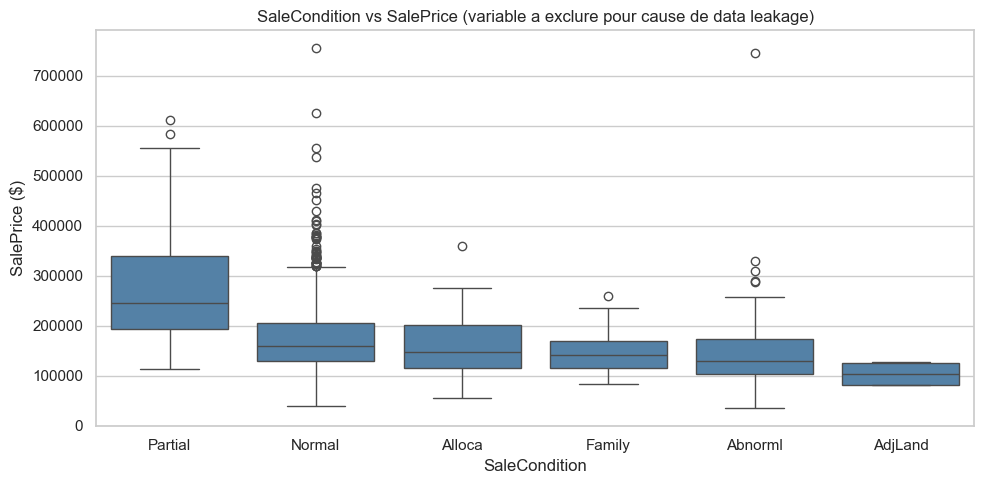

Effectifs et medianes par SaleCondition :
               count median_str
SaleCondition                  
Abnorml          101  130,000 $
AdjLand            4  104,000 $
Alloca            12  148,145 $
Family            20  140,500 $
Normal          1198  160,000 $
Partial          125  244,600 $


In [24]:
# Boxplot SaleCondition vs SalePrice
# SaleCondition est tres predictive (Partial = construction inachevee, Abnorml = vente forcee, etc.)
# mais INUTILISABLE en production car cette information n'est connue qu'apres la signature
ordre = (
    df.groupby("SaleCondition")[NOM_CIBLE]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="SaleCondition",
    y=NOM_CIBLE,
    order=ordre,
    ax=ax,
    color="steelblue",
)
ax.set_title("SaleCondition vs SalePrice (variable a exclure pour cause de data leakage)")
ax.set_xlabel("SaleCondition")
ax.set_ylabel(f"{NOM_CIBLE} ($)")
plt.tight_layout()
plt.show()

print("Effectifs et medianes par SaleCondition :")
resume = df.groupby("SaleCondition")[NOM_CIBLE].agg(["count", "median"])
resume["median_str"] = resume["median"].apply(lambda x: f"{x:,.0f} $")
print(resume[["count", "median_str"]])

### Observation : SaleCondition est très prédictive

Les médianes par modalité parlent d'elles-mêmes :

| SaleCondition | Effectif | Médiane | Lecture métier |
|---|---|---|---|
| `Partial` | 125 | **244 600 $** | Vente partielle (constructions neuves vendues avant achèvement) : les + chères |
| `Normal` | **1198** | 160 000 $ | Vente classique, le cas majoritaire |
| `Alloca` | 12 | 148 145 $ | Allocation |
| `Family` | 20 | 140 500 $ | Vente entre membres d'une famille |
| `Abnorml` | 101 | 130 000 $ | Vente "anormale" : saisie, succession, divorce |
| `AdjLand` | 4 | 104 000 $ | Ajustement de terrain : les moins chères |

`Partial` est **1.5x plus cher** que `Normal`, et l'écart entre `Partial` (244 600 $) et `AdjLand` (104 000 $) est de **2.35x**.

Si on utilisait cette variable dans le modèle, il "apprendrait" que `Partial = prix élevé` et `Abnorml = prix bas`. Le RMSE baisserait sensiblement. **Mais à T1 (estimation par l'agent), on ne sait pas si la vente sera Partial, Normal ou Abnorml** : ces conditions ne se révèlent qu'au moment de la signature.

C'est exactement pour cela qu'on l'exclut.

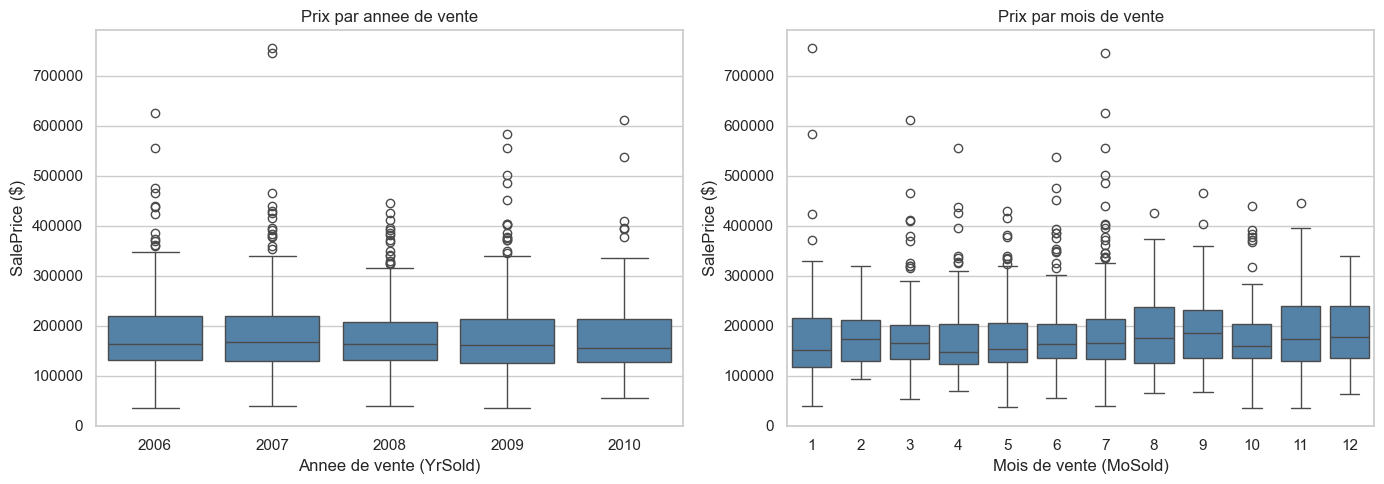

In [25]:
# YrSold et MoSold : variables temporelles
# A priori, la periode 2006-2010 est relativement stable a Ames : ces variables devraient peu impacter le prix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="YrSold", y=NOM_CIBLE, ax=axes[0], color="steelblue")
axes[0].set_title("Prix par annee de vente")
axes[0].set_xlabel("Annee de vente (YrSold)")
axes[0].set_ylabel(f"{NOM_CIBLE} ($)")

sns.boxplot(data=df, x="MoSold", y=NOM_CIBLE, ax=axes[1], color="steelblue")
axes[1].set_title("Prix par mois de vente")
axes[1].set_xlabel("Mois de vente (MoSold)")
axes[1].set_ylabel(f"{NOM_CIBLE} ($)")

plt.tight_layout()
plt.show()

### Observations de la section 7

Les boxplots `YrSold` et `MoSold` confirment leur faible pouvoir prédictif :

- **`YrSold` (2006-2010)** : les boxplots sont **quasiment identiques d'une année à l'autre**. Le marché d'Ames n'a pas significativement varié sur cette période (r = -0.029)
- **`MoSold`** : très légère hausse aux mois 7 et 12, mais l'effet est marginal (r = +0.046)

**Décision finale** : on exclut au total **4 variables** du modèle, mais en deux temps pour pouvoir réutiliser `YrSold` au feature engineering.

| Variable | Raison d'exclusion | Quand l'exclure | Coût en performance |
|---|---|---|---|
| `SaleType` | Type de transaction connu à T5 | dans `preprocessing.py` | Modéré |
| `SaleCondition` | Condition de vente connue à T5 | dans `preprocessing.py` | Significatif |
| `MoSold` | Mois de vente inconnu à T1 | dans `preprocessing.py` | Négligeable |
| `YrSold` | Année de vente inconnue à T1 | dans `features.py` après calcul des âges | Négligeable |

**Code à appliquer en preprocessing** :

```python
# Dans preprocessing.py : on n'exclut que 3 variables
variables_a_exclure = ["SaleType", "SaleCondition", "MoSold"]
df = df.drop(columns=variables_a_exclure)
```

**Cas particulier de `YrSold`** : on l'utilise pour calculer les âges (`building_age = YrSold - YearBuilt`), puis on la supprime dans `features.py`. En production (inférence par l'API), on remplacera `YrSold` par l'année courante (2026 par exemple) via un paramètre.

**Argument soutenance** : on accepte une légère baisse de performance pour obtenir un modèle réellement utilisable en production. C'est ce trade-off qui distingue un projet académique d'un projet pro.

## 8. Synthèse et décisions pour le preprocessing

Cette dernière section consolide les décisions issues de l'analyse exploratoire et donne le cahier des charges du preprocessing à venir.

### État du dataset à la fin de l'EDA

| Métrique | Valeur |
|---|---|
| Nombre de lignes | 1 460 |
| Nombre de colonnes | 81 (1 cible + 80 features) |
| Variables numériques | 38 |
| Variables catégorielles | 43 |
| Colonnes avec NaN | 19 (dont 17 structurels) |
| Outliers identifiés à supprimer | 2 (Id 524 et 1299) |
| Variables à exclure (leakage) | 4 (dont 3 dans preprocessing et 1 dans features) |

### Cible : `SalePrice`

| Statistique | Valeur |
|---|---|
| Min | 34 900 $ |
| Médiane | 163 000 $ |
| Moyenne | 180 921 $ |
| Max | 755 000 $ |
| Skewness brute | +1.88 |
| Skewness après `log1p` | +0.12 |

### Les décisions consolidées

| # | Décision | Justification métier | Action |
|---|---|---|---|
| 1 | Transformer la cible avec `log1p` | Skewness +1.88, aligne avec la métrique Kaggle officielle | `y = np.log1p(df["SalePrice"])` |
| 2 | Supprimer 2 outliers `GrLivArea` | Maisons en construction inachevée non représentatives | `df = df[~((df.GrLivArea > 4000) & (df.SaleCondition == "Partial"))]` |
| 3a | Exclure 3 variables dans `preprocessing.py` | `SaleType`, `SaleCondition`, `MoSold` inconnues lors de l'estimation | `df.drop(columns=["SaleType", "SaleCondition", "MoSold"])` |
| 3b | Supprimer `YrSold` après calcul des âges | Utilisée pour `building_age` et al., puis exclue (leakage) | Effectué dans `features.py` (fonction `creer_ages`) |
| 4 | Supprimer la colonne `Id` | Identifiant sans valeur prédictive | `df = df.drop(columns=["Id"])` |
| 5 | Imputer 15 variables catégorielles structurelles avec `"None"` | NaN signifie "non applicable", pas donnée manquante | `SimpleImputer(strategy="constant", fill_value="None")` |
| 6 | Imputer 2 variables numériques structurelles avec `0` | NaN signifie absence de garage ou parement | `SimpleImputer(strategy="constant", fill_value=0)` |
| 7 | Imputer `LotFrontage` par médiane de quartier | Vraie donnée manquante, lien fort au `Neighborhood` | Groupby `Neighborhood` puis médiane |
| 8 | Encodage : `OrdinalEncoder` pour qualités, `OneHotEncoder` pour nominales | Variables qualité monotones, autres sans ordre | `ColumnTransformer([...])` |

### Feature engineering planifié

| Feature créée | Formule | Utilité |
|---|---|---|
| `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` | Combine 3 features corrélées en 1 plus prédictive |
| `TotalPorchSF` | Somme des 5 types de porche | Surface extérieure totale |
| `TotalBathrooms` | `FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath` | Nombre équivalent de salles de bain complètes |
| `building_age` | `annee_reference - YearBuilt` | Âge du bâtiment (proxy de la dépréciation) |
| `remodel_age` | `annee_reference - YearRemodAdd` | Temps depuis la dernière rénovation |
| `garage_age` | `annee_reference - GarageYrBlt` (si garage) | Âge du garage |
| `has_pool` | `(PoolArea > 0).astype(int)` | Présence d'une piscine |
| `has_garage` | `(GarageArea > 0).astype(int)` | Présence d'un garage |
| `has_basement` | `(TotalBsmtSF > 0).astype(int)` | Présence d'un sous-sol |
| `has_fireplace` | `(Fireplaces > 0).astype(int)` | Présence d'une cheminée |

Note sur `annee_reference` : pendant l'entraînement c'est `YrSold` (utilisée puis supprimée), pendant l'inférence c'est l'année courante (passée en paramètre à l'API).

### Conclusion

Bilan de l'EDA :

- **1 458 lignes utilisables** sur les 1 460 initiales (après suppression de 2 outliers)
- **76 features finales utilisables** sur les 80 initiales (exclusion de `Id`, `SaleType`, `SaleCondition`, `MoSold`, `YrSold`), enrichies de **11 nouvelles features** créées en feature engineering
- **Soit 87 colonnes au final** dans le DataFrame prêt pour la modélisation
- **Cible transformée** : `log1p(SalePrice)` pour les modèles linéaires
- **Top features attendues** : `OverallQual`, `GrLivArea`, `TotalSF` (créée), `GarageCars`, `Neighborhood`
- **Stratégie modélisation** : tester Linear, Ridge, Lasso, RandomForest, XGBoost, LightGBM avec un `Pipeline` sklearn anti-leakage

Les décisions ci-dessus seront implémentées en pipeline `sklearn` réutilisable dans le code source, les tests unitaires, le pipeline DVC et l'API FastAPI.